# 1. Set the Data:

In [1]:
import os
dataset_path = r'C:\Users\husse\Desktop\Senior Project\Datasets\Final_Plant_Dataset_(Types)_2.0\train'
class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

Found 25 classes: ['Apple', 'Blueberry', 'Cassava', 'Cherry', 'Chili', 'Coffee', 'Corn', 'Cucumber', 'Grape', 'Guava', 'Jamun', 'Lemon', 'Mango', 'Orange', 'Peach', 'Pepper', 'Potato', 'Raspberry', 'Rice', 'Soybean', 'Strawberry', 'Sugarcane', 'Tea', 'Tomato', 'Wheat']


# 2. Display sample images from each calss:

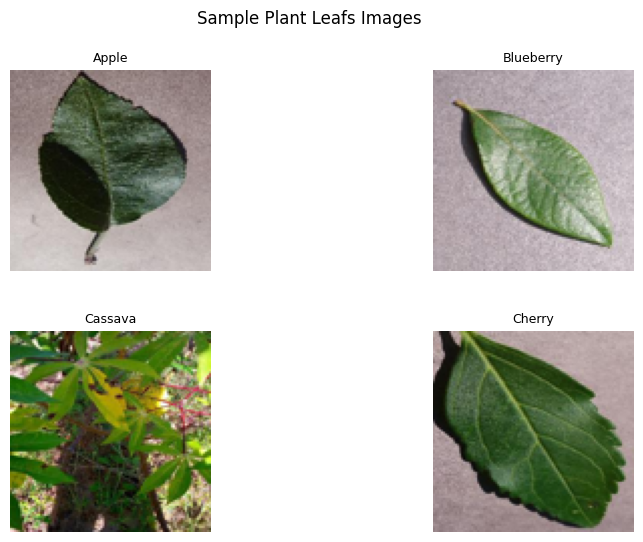

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

plt.figure(figsize=(10, 6))  


for i, class_name in enumerate(class_names[:4]):  
    class_dir = os.path.join(dataset_path, class_name)
    img_files = os.listdir(class_dir)
    
    img_path = os.path.join(class_dir, img_files[0])
    img = Image.open(img_path)
    img = img.resize((100, 100))  
    
    plt.subplot(2, 2, i+1)  # This works now because i+1 will only go from 1 to 4
    plt.imshow(img)
    plt.title(class_name, fontsize=9) 
    plt.axis('off')

plt.subplots_adjust(wspace=0.2, hspace=0.3)  
plt.suptitle('Sample Plant Leafs Images', fontsize=12)
plt.show()

# 3. Create class distrubution table and chart ... count images per class:


Class Distribution Table:


,Class,Number of Images
0,Apple,6216
1,Blueberry,1452
2,Cassava,1753
3,Cherry,2807
4,Chili,386
5,Coffee,882
6,Corn,5852
7,Cucumber,552
8,Grape,5777
9,Guava,392


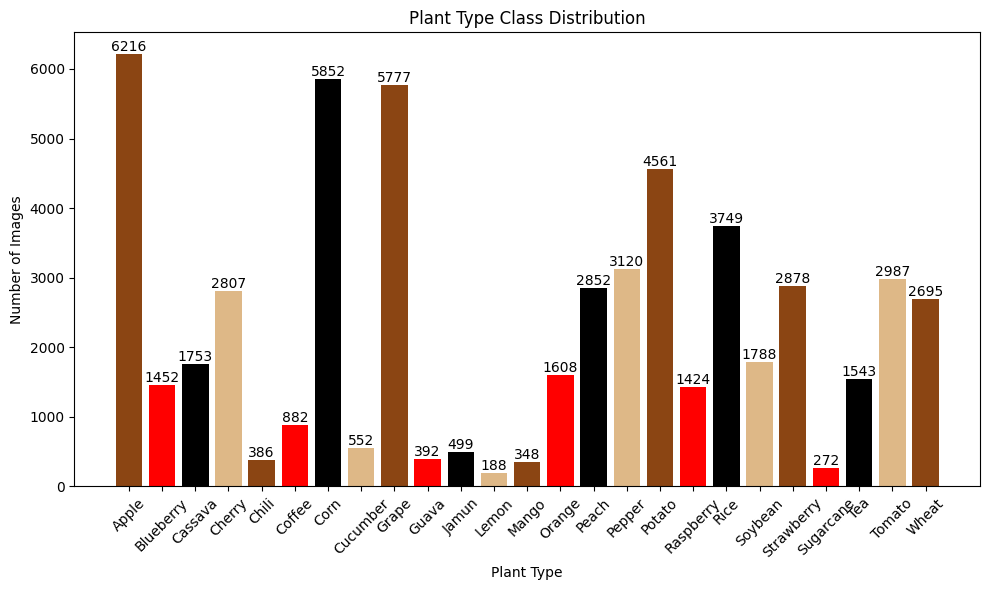

In [3]:
class_counts = []
for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_dir))
    class_counts.append(count)


df = pd.DataFrame({
    'Class': class_names,
    'Number of Images': class_counts
})


print("\nClass Distribution Table:")
display(df)

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, class_counts, color=['#8B4513', '#FF0000', '#000000', '#DEB887'])

plt.title('Plant Type Class Distribution')
plt.xlabel('Plant Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [4]:
import os
from PIL import Image

def get_dataset_stats(root_dir):
    total_images = 0
    class_counts = {}
    img_types = set()
    resolutions = set()
    color_modes = set()
    
    
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(images)
            total_images += len(images)
            
            
            if images:
                sample_img = os.path.join(class_path, images[0])
                with Image.open(sample_img) as img:
                    img_types.add(os.path.splitext(images[0])[1].upper().replace('.', ''))
                    resolutions.add(img.size)
                    color_modes.add(img.mode)
    
    return {
        'total_images': total_images,
        'class_distribution': class_counts,
        'image_types': list(img_types),
        'resolutions': list(resolutions),
        'color_modes': list(color_modes)
    }

# Analyze training and test sets
train_stats = get_dataset_stats(r'C:\Users\husse\Desktop\Senior Project\Datasets\Final_Plant_Dataset_(Types)_2.0\train')
test_stats = get_dataset_stats(r'C:\Users\husse\Desktop\Senior Project\Datasets\Final_Plant_Dataset_(Types)_2.0\test')

# Print report
print(f"Total Images: {train_stats['total_images'] + test_stats['total_images']}")
print(f"Training Set: {train_stats['total_images']} ({train_stats['total_images']/(train_stats['total_images']+test_stats['total_images']):.0%})")
print(f"Test Set: {test_stats['total_images']} ({test_stats['total_images']/(train_stats['total_images']+test_stats['total_images']):.0%})")
print(f"Image Type(s): {', '.join(train_stats['image_types'])}")
print(f"Resolution(s): {', '.join([f'{w}x{h}' for (w,h) in train_stats['resolutions']])}")
print(f"Color Channels: {', '.join(train_stats['color_modes'])}")

#Class distribution table
print("\nClass Distribution:")
for class_name, count in train_stats['class_distribution'].items():
    print(f"- {class_name}: {count} images")

Total Images: 70741
Training Set: 56581 (80%)
Test Set: 14160 (20%)
Image Type(s): JPG
Resolution(s): 6000x4000, 2592x1944, 224x224, 2048x1152, 768x1024, 4160x1968, 300x168, 256x256, 576x387
Color Channels: RGB

Class Distribution:
- Apple: 6216 images
- Blueberry: 1452 images
- Cassava: 1753 images
- Cherry: 2807 images
- Chili: 386 images
- Coffee: 882 images
- Corn: 5852 images
- Cucumber: 552 images
- Grape: 5777 images
- Guava: 392 images
- Jamun: 499 images
- Lemon: 188 images
- Mango: 348 images
- Orange: 1608 images
- Peach: 2852 images
- Pepper: 3120 images
- Potato: 4561 images
- Raspberry: 1424 images
- Rice: 3749 images
- Soybean: 1788 images
- Strawberry: 2878 images
- Sugarcane: 272 images
- Tea: 1543 images
- Tomato: 2987 images
- Wheat: 2695 images


# 4. Now we start Training:

## 4.1. Import Libraries:

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

## 4.2. Define Paths & Parameters:

In [6]:
DATASET_ROOT = r'C:\Users\husse\Desktop\Senior Project\Datasets\Final_Plant_Dataset_(Types)_2.0'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = (224, 224)

BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(class_names) 

## 4.3. Create Datasets (NO AUGMENTATION):

In [7]:
# Normalization function (only rescale)
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Load training data (we'll split it internally for validation)
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    seed=42,
    shuffle=True
)

# Load test data (no shuffle, no augmentation)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=42
)

# Apply normalization
train_ds_full = train_ds_full.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_full = train_ds_full.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 56581 files belonging to 25 classes.
Found 14160 files belonging to 25 classes.


## 4.4. Create Train/Validation Split (from train_ds_full):

In [8]:
# We'll use 85% for training, 15% for validation
train_size = int(0.85 * len(train_ds_full))
val_size = len(train_ds_full) - train_size

train_ds = train_ds_full.take(train_size)
val_ds = train_ds_full.skip(train_size)

## 4.5. Build Simple CNN Model (No Augmentation):

In [9]:
model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,825 (2.03 MB)

 Trainable params: 532,825 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

## 4.6. Callbacks (Save Best, Early Stop):

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_plant_model_no_aug.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

## 4.7. Train the model:

In [11]:
print("\n🚀 Starting Training (No Augmentation)...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


🚀 Starting Training (No Augmentation)...

Epoch 1/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 549s 364ms/step - accuracy: 0.2733 - loss: 2.3389 - val_accuracy: 0.5861 - val_loss: 1.3097
Epoch 2/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 532s 354ms/step - accuracy: 0.5697 - loss: 1.3289 - val_accuracy: 0.7974 - val_loss: 0.6685
Epoch 3/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 536s 357ms/step - accuracy: 0.7228 - loss: 0.8547 - val_accuracy: 0.8655 - val_loss: 0.4556
Epoch 4/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 558s 371ms/step - accuracy: 0.7895 - loss: 0.6593 - val_accuracy: 0.9011 - val_loss: 0.3332
Epoch 5/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 553s 368ms/step - accuracy: 0.8329 - loss: 0.5433 - val_accuracy: 0.9091 - val_loss: 0.2920
Epoch 6/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 543s 361ms/step - accuracy: 0.8558 - loss: 0.4662 - val_accuracy: 0.9315 - val_loss: 0.2258
Epoch 7/10
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 542s 361ms/step - accuracy: 0.8733 - loss: 0.4078 - val_accuracy: 0.9272 - val_loss: 0.2356
Epoch 8/10
1503/150

## 4.8. Evaluate on Test Set:

In [12]:
print("\n🔍 Evaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")


🔍 Evaluating on Test Set...
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - accuracy: 0.9556 - loss: 0.1436

✅ Final Test Accuracy: 0.9558


## 4.9. Plot the Results:

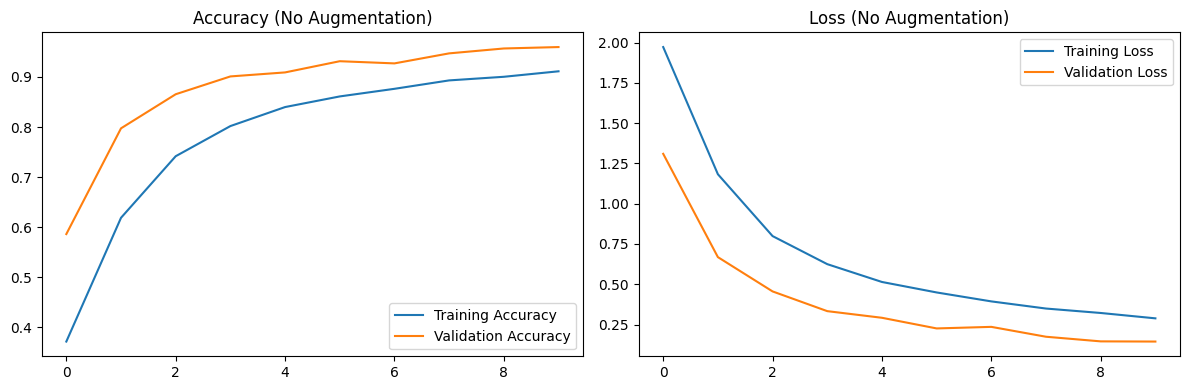

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy (No Augmentation)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss (No Augmentation)')

plt.tight_layout()
plt.show()

## 4.10. Save the model:

In [14]:
model.save('final_plant_model_no_aug.keras')
print("\n💾 Model saved as 'final_plant_model_no_aug.keras'")


💾 Model saved as 'final_plant_model_no_aug.keras'


## 4.11. Testing the model:

In [1]:
import tensorflow as tf
from PIL import Image
import numpy as np
import os

# ----------------------------
# 1. LOAD THE SAVED MODEL
# ----------------------------
model_path = "final_plant_model_no_aug.keras"  
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully!")

# ----------------------------
# 2. DEFINE CLASS NAMES 
# ----------------------------
dataset_train_dir = r'C:\Users\husse\Desktop\Senior Project\Datasets\Final_Plant_Dataset_(Types)_2.0\train'
class_names = sorted([d for d in os.listdir(dataset_train_dir) 
                      if os.path.isdir(os.path.join(dataset_train_dir, d))])
print("Class names (in order):", class_names)

# ----------------------------
# 3. PREDICT A SINGLE IMAGE
# ----------------------------
def predict_image(image_path, model, class_names, img_size=(224, 224)):
    """
    Predict the plant type of a leaf image.
    """
    # Load and preprocess the image
    img = Image.open(image_path)
    img = img.resize(img_size)
    img_array = np.array(img) / 255.0            
    img_array = np.expand_dims(img_array, axis=0) 

    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    confidence = predictions[0][predicted_class_idx] * 100

    predicted_class = class_names[predicted_class_idx]
    return predicted_class, confidence

# ----------------------------
# 4. USE IT
# ----------------------------
your_image_path = r"C:\Users\husse\Desktop\Senior Project\Datasets\Apple_00000.jpg"

# Run prediction
predicted_label, confidence = predict_image(your_image_path, model, class_names)

# Show result
print(f"\n🔍 Prediction Result:")
print(f"→ Predicted Plant: {predicted_label}")
print(f"→ Confidence: {confidence:.2f}%")

✅ Model loaded successfully!
Class names (in order): ['Apple', 'Blueberry', 'Cassava', 'Cherry', 'Chili', 'Coffee', 'Corn', 'Cucumber', 'Grape', 'Guava', 'Jamun', 'Lemon', 'Mango', 'Orange', 'Peach', 'Pepper', 'Potato', 'Raspberry', 'Rice', 'Soybean', 'Strawberry', 'Sugarcane', 'Tea', 'Tomato', 'Wheat']

🔍 Prediction Result:
→ Predicted Plant: Apple
→ Confidence: 98.43%
